# SingBERT 5-fold CV Fine-Tuning and Baseline Comparison

### Install Dependencies

Run once per Colab session.

In [1]:
!pip install -q transformers torch scikit-learn vaderSentiment accelerate


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 2.3 MB/s eta 0:00:00


## Confirm GPU is Available

In [2]:
import torch
DEVICE = 0 if torch.cuda.is_available() else -1
print(f"Device: {'GPU' if DEVICE == 0 else 'CPU'}")
print(f"PyTorch version: {torch.__version__}")
if DEVICE == 0:
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")


Device: GPU
PyTorch version: 2.10.0+cu128
CUDA device: Tesla T4


## Upload Labelled CSV


In [3]:
from google.colab import files
uploaded = files.upload()
print("Uploaded:", list(uploaded.keys()))


Saving cosem_pilot_sample.csv to cosem_pilot_sample.csv
Uploaded: ['cosem_pilot_sample.csv']


## Import Libraries and Label Space

In [4]:
import csv
import json
import warnings
import numpy as np
import torch
from collections import Counter
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from transformers import (
    pipeline, AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments, DataCollatorWithPadding,
)
from torch.utils.data import Dataset

warnings.filterwarnings("ignore")
torch.manual_seed(42)
np.random.seed(42)

LABEL2ID = {"neg": 0, "neu": 1, "pos": 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

CSV_PATH = "cosem_pilot_sample.csv"
SINGBERT = "zanelim/singbert"

print("Imports OK")


Imports OK


## Load Labelled Data


In [5]:
with open(CSV_PATH, encoding="utf-8") as f:
    rows = [r for r in csv.DictReader(f) if r["gold_label"].strip() in LABEL2ID]

texts  = [r["text"] for r in rows]
labels = [LABEL2ID[r["gold_label"].strip()] for r in rows]
probes = [r["probe_tag"].strip() for r in rows]

print(f"Loaded {len(rows)} labelled items")
print(f"Class distribution: {Counter(r['gold_label'].strip() for r in rows)}")
print(f"Probe-tag distribution: {Counter(probes)}")


Loaded 100 labelled items
Class distribution: Counter({'neg': 53, 'neu': 27, 'pos': 20})
Probe-tag distribution: Counter({'': 44, 'H2_codeswitch': 28, 'H1_particle': 17, 'H3_sarcasm': 11})


## Baseline 1: VADER

Lexicon-based; runs on CPU instantly.


In [6]:
v = SentimentIntensityAnalyzer()
def vader_predict(t):
    c = v.polarity_scores(t)["compound"]
    if c >= 0.05:  return LABEL2ID["pos"]
    if c <= -0.05: return LABEL2ID["neg"]
    return LABEL2ID["neu"]

vader_preds = [vader_predict(t) for t in texts]
print(f"VADER predictions: {Counter(vader_preds)}")
print(f"  (gold reference: {Counter(labels)})")


VADER predictions: Counter({2: 42, 1: 35, 0: 23})
  (gold reference: Counter({0: 53, 1: 27, 2: 20}))


## Baseline 2: DistilBERT-SST-2

English-only binary sentiment model. Note: it can only predict pos/neg, never neutral, so the 28 neutral items are auto-wrong against this baseline. The aggregation cell handles this accordinly


In [9]:
print("Loading DistilBERT (downloads ~250MB on first run)...")
db = pipeline("sentiment-analysis",
              model="distilbert-base-uncased-finetuned-sst-2-english",
              device=DEVICE)

def db_predict(t):
    return LABEL2ID["pos"] if db(t)[0]["label"] == "POSITIVE" else LABEL2ID["neg"]

db_preds = [db_predict(t) for t in texts]
print(f"DistilBERT predictions: {Counter(db_preds)}")
print(f"  (gold reference: {Counter(labels)})")


Loading DistilBERT (downloads ~250MB on first run)...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

DistilBERT predictions: Counter({0: 77, 2: 23})
  (gold reference: Counter({0: 53, 1: 27, 2: 20}))


## Baseline 3: XLM-R-twitter-sentiment

Multilingual three-way model trained on Twitter data across eight languages.


In [10]:
print("Loading XLM-R-twitter (downloads ~1.1GB on first run)...")
xr = pipeline("sentiment-analysis",
              model="cardiffnlp/twitter-xlm-roberta-base-sentiment",
              device=DEVICE)

xr_label_map = {
    "Positive":"pos","positive":"pos",
    "Negative":"neg","negative":"neg",
    "Neutral":"neu","neutral":"neu",
}
def xr_predict(t):
    out = xr(t)[0]["label"]
    return LABEL2ID[xr_label_map.get(out, out.lower()[:3])]

xr_preds = [xr_predict(t) for t in texts]
print(f"XLM-R predictions: {Counter(xr_preds)}")
print(f"  (gold reference: {Counter(labels)})")


Loading XLM-R-twitter (downloads ~1.1GB on first run)...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-xlm-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


XLM-R predictions: Counter({0: 36, 1: 36, 2: 28})
  (gold reference: Counter({0: 53, 1: 27, 2: 20}))


## Set up SingBERT Fine-Tuning

Defines the dataset class, computes class weights to handle the dataset imbalance, and creates a custom Trainer that uses weighted cross-entropy loss.


In [22]:
class TextDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        item = {k: torch.tensor(v[i]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[i])
        return item

# Class Weights
class_counts = Counter(labels)
n_total = sum(class_counts.values())
raw_weights = torch.tensor([
    n_total / (3 * class_counts[i]) for i in range(3)
], dtype=torch.float)
class_weights = raw_weights ** 0.7   # moderate damping
print(f"Class weights (neg, neu, pos): {[round(w, 3) for w in class_weights.tolist()]}")

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels_ = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fn = torch.nn.CrossEntropyLoss(
            weight=class_weights.to(logits.device)
        )
        loss = loss_fn(logits, labels_)
        return (loss, outputs) if return_outputs else loss

# Pre-load tokeniser once (will be reused across folds)
print("Loading SingBERT tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(SINGBERT)
print("Setup OK")


Class weights (neg, neu, pos): [0.723, 1.159, 1.43]
Loading SingBERT tokenizer...
Setup OK


## 5-Fold Cross-Validation Fine-Tuning


In [23]:
from transformers import EarlyStoppingCallback

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
sb_preds_per_fold = [None] * len(texts)
fold_f1_scores = []

for fold_idx, (train_idx, test_idx) in enumerate(
    skf.split(texts, labels), start=1
):
    print(f"\n--- Fold {fold_idx}/5 ---")
    train_texts = [texts[i] for i in train_idx]
    train_labels = [labels[i] for i in train_idx]
    test_texts = [texts[i] for i in test_idx]
    test_labels = [labels[i] for i in test_idx]

    from sklearn.model_selection import train_test_split
    tr_texts, dev_texts, tr_labels, dev_labels = train_test_split(
        train_texts, train_labels,
        test_size=0.10,
        random_state=42,
        stratify=train_labels,
    )

    tr_enc = tokenizer(tr_texts, truncation=True, padding=True, max_length=128)
    dev_enc = tokenizer(dev_texts, truncation=True, padding=True, max_length=128)
    test_enc = tokenizer(test_texts, truncation=True, padding=True, max_length=128)
    tr_ds = TextDataset(tr_enc, tr_labels)
    dev_ds = TextDataset(dev_enc, dev_labels)
    test_ds = TextDataset(test_enc, test_labels)

    model = AutoModelForSequenceClassification.from_pretrained(
        SINGBERT, num_labels=3,
        id2label=ID2LABEL, label2id=LABEL2ID,
    )

    args = TrainingArguments(
        output_dir=f"./singbert_fold{fold_idx}",
        num_train_epochs=8,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=16,
        learning_rate=3e-5,
        warmup_ratio=0.1,
        weight_decay=0.01,
        logging_steps=20,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        save_total_limit=1,
        report_to="none",
        seed=42,
    )

    def compute_metrics(eval_pred):
        preds, labs = eval_pred
        preds = preds.argmax(axis=1)
        return {"f1_macro": f1_score(labs, preds, average="macro", zero_division=0)}

    trainer = WeightedTrainer(
        model=model,
        args=args,
        train_dataset=tr_ds,
        eval_dataset=dev_ds,
        processing_class=tokenizer,
        data_collator=DataCollatorWithPadding(tokenizer),
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )
    trainer.train()

    raw_preds = trainer.predict(test_ds).predictions
    fold_preds = raw_preds.argmax(axis=1).tolist()
    for i, p in zip(test_idx, fold_preds):
        sb_preds_per_fold[i] = int(p)

    fold_f1 = f1_score(test_labels, fold_preds, average="macro")
    fold_f1_scores.append(fold_f1)
    print(f"Fold {fold_idx} Macro-F1: {fold_f1:.3f}")

    del model, trainer
    if torch.cuda.is_available(): torch.cuda.empty_cache()

print(f"\n=== 5-Fold Mean Macro-F1: {np.mean(fold_f1_scores):.3f} "
      f"(std {np.std(fold_f1_scores):.3f}) ===")


--- Fold 1/5 ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: zanelim/singbert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized 

Epoch,Training Loss,Validation Loss,F1 Macro
1,No log,1.094817,0.181818
2,No log,1.047884,0.222222
3,1.044726,0.975525,0.366667
4,1.044726,0.927271,0.464646
5,0.676019,1.157193,0.600000
6,0.676019,1.092460,0.464646
7,0.411673,0.988842,0.222222


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Fold 5 Macro-F1: 0.361

=== 5-Fold Mean Macro-F1: 0.431 (std 0.040) ===


## Aggregate and Print Results

Model,macro-F1,accuracy,n
VADER,0.496,0.500,100
DistilBERT-SST2,0.620,0.712,73
XLM-R-twitter,0.624,0.630,100
SingBERT-FT (5fold-CV),0.456,0.570,100


Probe,n,macro-F1,accuracy
H1_particle,17,0.419,0.765
H2_codeswitch,28,0.383,0.714
H3_sarcasm,11,0.178,0.364


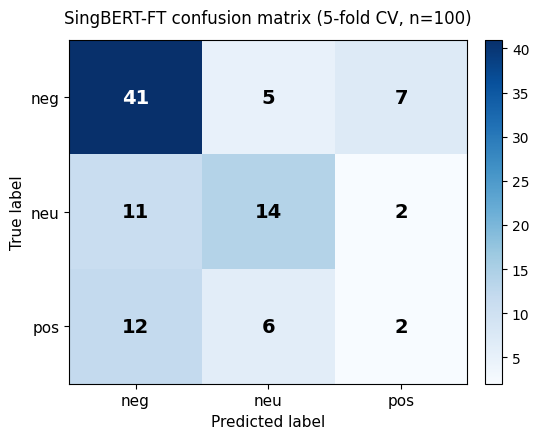

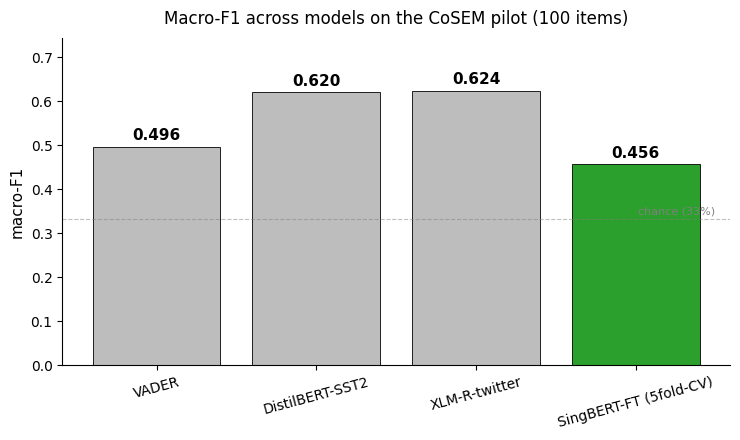

Saved: pilot_results_v2.json, confusion_matrix.png, model_comparison.png


In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Compute Model-Level Metrics
def report(name, preds, labs, exclude_neu_for=None):
    if exclude_neu_for == name:
        idx = [i for i, l in enumerate(labs) if l != LABEL2ID["neu"]]
        labs = [labs[i] for i in idx]
        preds = [preds[i] for i in idx]
    macro = f1_score(labs, preds, average="macro")
    acc = sum(1 for p, l in zip(preds, labs) if p == l) / len(labs)
    return macro, acc, len(labs)

results = {}
for name, preds in [
    ("VADER",                  vader_preds),
    ("DistilBERT-SST2",        db_preds),
    ("XLM-R-twitter",          xr_preds),
    ("SingBERT-FT (5fold-CV)", sb_preds_per_fold),
]:
    macro, acc, n = report(name, preds, labels, exclude_neu_for="DistilBERT-SST2")
    results[name] = {"macro_f1": macro, "accuracy": acc, "n_evaluated": n}

# Visual 1: Model Comparison Table
df_models = pd.DataFrame([
    {"Model": name, "macro-F1": r["macro_f1"],
     "accuracy": r["accuracy"], "n": r["n_evaluated"]}
    for name, r in results.items()
])

styled_models = (
    df_models.style
    .format({"macro-F1": "{:.3f}", "accuracy": "{:.3f}"})
    .background_gradient(subset=["macro-F1"], cmap="YlGn", vmin=0.3, vmax=0.85)
    .background_gradient(subset=["accuracy"], cmap="Blues", vmin=0.3, vmax=0.85)
    .set_caption("Table 1: Model comparison on 100-item CoSEM pilot")
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-weight", "bold"), ("font-size", "14px"),
                   ("text-align", "left"), ("padding-bottom", "8px")]},
        {"selector": "th",
         "props": [("background-color", "#f0f0f0"), ("text-align", "center"),
                   ("padding", "6px 10px")]},
        {"selector": "td",
         "props": [("text-align", "right"), ("padding", "5px 10px")]},
    ])
    .hide(axis="index")
)
display(styled_models)

# Visual 2: per-Probe Breakdown
probe_breakdown = {}
for probe_name in ("H1_particle", "H2_codeswitch", "H3_sarcasm"):
    idx = [i for i, p in enumerate(probes) if p == probe_name]
    if idx:
        sub_labs = [labels[i] for i in idx]
        sub_preds = [sb_preds_per_fold[i] for i in idx]
        macro = f1_score(sub_labs, sub_preds, average="macro", zero_division=0)
        acc = sum(1 for p, l in zip(sub_preds, sub_labs) if p == l) / len(idx)
        probe_breakdown[probe_name] = {
            "n": len(idx), "macro_f1": macro, "accuracy": acc
        }

df_probes = pd.DataFrame([
    {"Probe": p, "n": r["n"],
     "macro-F1": r["macro_f1"], "accuracy": r["accuracy"]}
    for p, r in probe_breakdown.items()
])

styled_probes = (
    df_probes.style
    .format({"macro-F1": "{:.3f}", "accuracy": "{:.3f}"})
    .background_gradient(subset=["macro-F1"], cmap="YlGn", vmin=0.3, vmax=0.85)
    .set_caption("Table 2: SingBERT-FT per-probe-tag breakdown")
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-weight", "bold"), ("font-size", "14px"),
                   ("text-align", "left"), ("padding-bottom", "8px")]},
        {"selector": "th",
         "props": [("background-color", "#f0f0f0"), ("text-align", "center"),
                   ("padding", "6px 10px")]},
        {"selector": "td",
         "props": [("text-align", "right"), ("padding", "5px 10px")]},
    ])
    .hide(axis="index")
)
display(styled_probes)

# Visual 3: Confusion Matrix Heatmap
cm = confusion_matrix(labels, sb_preds_per_fold, labels=[0, 1, 2])

fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(cm, cmap="Blues", aspect="auto")

class_names = ["neg", "neu", "pos"]
ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(class_names, fontsize=11)
ax.set_yticklabels(class_names, fontsize=11)
ax.set_xlabel("Predicted label", fontsize=11)
ax.set_ylabel("True label", fontsize=11)
ax.set_title("SingBERT-FT confusion matrix (5-fold CV, n=100)",
             fontsize=12, pad=12)

threshold = cm.max() / 2.0
for i in range(3):
    for j in range(3):
        ax.text(j, i, str(cm[i, j]),
                ha="center", va="center",
                color="white" if cm[i, j] > threshold else "black",
                fontsize=14, fontweight="bold")

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# Visual 4: Model-Comparison Bar Chart
fig, ax = plt.subplots(figsize=(7.5, 4.5))
model_names = list(results.keys())
f1_values = [results[n]["macro_f1"] for n in model_names]
colors = ["#bdbdbd", "#bdbdbd", "#bdbdbd", "#2ca02c"]

bars = ax.bar(model_names, f1_values, color=colors, edgecolor="black", linewidth=0.6)

for bar, val in zip(bars, f1_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
            f"{val:.3f}", ha="center", fontsize=11, fontweight="bold")

ax.set_ylabel("macro-F1", fontsize=11)
ax.set_ylim(0, max(f1_values) + 0.12)
ax.set_title("Macro-F1 across models on the CoSEM pilot (100 items)",
             fontsize=12, pad=10)
ax.tick_params(axis="x", labelsize=10, rotation=15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.axhline(y=1/3, linestyle="--", color="grey", alpha=0.5, linewidth=0.8)
ax.text(len(model_names)-0.5, 1/3 + 0.01, "chance (33%)",
        fontsize=8, color="grey", ha="right")
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# Save Raw Output
all_output = {
    "models": results,
    "singbert_per_probe": probe_breakdown,
    "singbert_per_item_predictions": sb_preds_per_fold,
    "fold_f1_scores": fold_f1_scores,
    "confusion_matrix": cm.tolist(),
    "class_distribution": dict(Counter(r['gold_label'].strip() for r in rows)),
}
with open("pilot_results_v2.json", "w") as f:
    json.dump(all_output, f, indent=2)

print("Saved: pilot_results_v2.json, confusion_matrix.png, model_comparison.png")

## Download the Results JSON


In [29]:
from google.colab import files
files.download("pilot_results_v2.json")
files.download("confusion_matrix.png")
files.download("model_comparison.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>